In [1]:
import numpy as np
import sympy as sp
from sympy import sqrt, Matrix, binomial
import matplotlib.pyplot as plt
from sympy.physics.quantum import TensorProduct
from sympy.physics.quantum.trace import Tr
from sympy import simplify, lambdify
from math import comb, isnan
%matplotlib inline

In [2]:
# Identity operators for ion and photon Hilbert spaces
id_ion = sp.eye(2)
id_photon = sp.eye(3)

# Basis vectors for the ion
ket_0_ion = sp.Matrix([1,0])
ket_1_ion = sp.Matrix([0,1])
bra_0_ion = ket_0_ion.T
bra_1_ion = ket_1_ion.T

# Basis vectors for the photon (Assume there is at most two photon at each optical mode)
ket_0_photon = sp.Matrix([1,0,0])
ket_1_photon = sp.Matrix([0,1,0])
ket_2_photon = sp.Matrix([0,0,1])

bra_0_photon = ket_0_photon.T
bra_1_photon = ket_1_photon.T
bra_2_photon = ket_2_photon.T

# Define Bell states for the ions
phi_plus = np.array((1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_0_ion) + TensorProduct(ket_1_ion, ket_1_ion)))
psi_plus = np.array((1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_1_ion) + TensorProduct(ket_1_ion, ket_0_ion)))
psi_minus = np.array((1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_1_ion) - TensorProduct(ket_1_ion, ket_0_ion)))
phi_minus = np.array((1/sqrt(2)) * (TensorProduct(ket_0_ion, ket_0_ion) - TensorProduct(ket_1_ion, ket_1_ion)))

In [3]:
def heralded_dm(dm):
    '''
    Get the heralded state for the elementary link.
    Note that we assume the heralded state is |Psi^+>. Other possible heralding pattern leads to state locally equivalent to this.
    
    Input:
    dm: The density operator in the form |ion1, photon1, ion2, photon2>.

    Output:
    A density operator for the remote ions.
    '''

    # Beam splitter: output mode |10> mapped to input modes. 
    o_10 = (1/sqrt(2)) * ((TensorProduct(id_ion, ket_0_photon, id_ion, ket_1_photon)) + TensorProduct(id_ion, ket_1_photon, id_ion, ket_0_photon))
    rho_10 = o_10.T @ dm @ o_10
    return (rho_10)
    
def normalize(dm):
    
    return dm / Tr(dm)

def amplitude_damping_kraus_sp(d):

    kraus_ops = []
    for k in range(d):
        K = Matrix.zeros(d, d)
        for n in range(k, d):
            amp = sqrt(binomial(n, k)) * ((1 - p)**((n - k)/2)) * (p**(k/2))
            K[n - k, n] = amp
        kraus_ops.append(K)
    
    return kraus_ops

def merge_els(p_vec, N_QPU):
    # This is not needed in the case of atom-based, since the elementary links are perfect after entanglement distillation.
    pI, pX, pY, pZ = p_vec
    num_links = N_QPU-1
    out_pI, out_pX, out_pY, out_pZ = pI, pX, pY, pZ

    for i in range(num_links-1):
        out_pI = out_pI * pI + out_pX * pX + out_pY * pY + out_pZ * pZ
        out_pX = out_pI * pX + out_pX * pI + out_pY * pZ + out_pZ * pY
        out_pY = out_pI * pY + out_pY * pI + out_pX * pZ + out_pZ * pX
        out_pZ = out_pI * pZ + out_pZ * pI + out_pX * pY + out_pY * pX
    result = np.array([out_pI, out_pX, out_pY, out_pZ])
    return result/np.sum(result)

def get_p_vec(dm):
    
    dm_np = np.array(dm)
    pI = (phi_plus.T @ dm_np @ phi_plus)[0][0]
    pX = (psi_plus.T @ dm_np @ psi_plus)[0][0]
    pY = (psi_minus.T @ dm_np @ psi_minus)[0][0]
    pZ = (phi_minus.T @ dm_np @ phi_minus)[0][0]

    # Assume local rotation back to pI (change Pauli frame)
    return np.array([pX, pI, pZ, pY])

def apply_ED_protocol(dm):

    input_dm = TensorProduct(dm, dm)
    x_gate = Matrix([[0,1], [1,0]])
    # |a, b, a, b>
    CNOT_alice = TensorProduct(ket_0_ion @ bra_0_ion, id_ion, id_ion, id_ion) + TensorProduct(ket_1_ion @ bra_1_ion, id_ion, x_gate, id_ion)
    CNOT_bob = TensorProduct(id_ion, ket_0_ion @ bra_0_ion, id_ion, id_ion) + TensorProduct(id_ion, ket_1_ion @ bra_1_ion, id_ion, x_gate)

    dm_cnot = CNOT_bob @ (CNOT_alice @ input_dm @ CNOT_alice.T) @ CNOT_bob.T
    post_select_dm = TensorProduct(id_ion, id_ion, bra_1_ion, bra_1_ion) * dm_cnot * TensorProduct(id_ion, id_ion, ket_1_ion, ket_1_ion)
    prob = Tr(post_select_dm)
    return normalize(post_select_dm), prob

# Symbolic expressions

In [4]:
# The excitation strength of the ion
q = sp.symbols('q')

# The total loss for one-side
p = sp.symbols('p')

# One-side ion-photon entangled state
# Assume the 0_ion is the bright state
# sqrt(1-epsilon) |10> + sqrt(1-epsilon) |01>
sp_ion_photon_key = sqrt(1-q) * TensorProduct(ket_1_ion, ket_0_photon) + sqrt(q) * TensorProduct(ket_0_ion, ket_1_photon)
sp_ion_photon_dm = sp_ion_photon_key @ sp_ion_photon_key.T

sp_joint_dm = TensorProduct(sp_ion_photon_dm, sp_ion_photon_dm)

# Define Kraus operators for the amplitude damping (max. number of photons = 2)
K_ops_amp = amplitude_damping_kraus_sp(3)
K_0_amp = K_ops_amp[0]
K_1_amp = K_ops_amp[1]
K_2_amp = K_ops_amp[2]

# Damp the first photon (State : |ion1, photon1, ion2, photon2>)
sp_joint_dm = TensorProduct(id_ion, K_0_amp, id_ion, id_photon) @ sp_joint_dm @ TensorProduct(id_ion, K_0_amp.T, id_ion, id_photon) + TensorProduct(id_ion, K_1_amp, id_ion, id_photon) @ sp_joint_dm @ TensorProduct(id_ion, K_1_amp.T, id_ion, id_photon) + TensorProduct(id_ion, K_2_amp, id_ion, id_photon) @ sp_joint_dm @ TensorProduct(id_ion, K_2_amp.T, id_ion, id_photon)

# Damp the second photon (State : |ion1, photon1, ion2, photon2>)
sp_joint_dm = TensorProduct(id_ion, id_photon, id_ion, K_0_amp) @ sp_joint_dm @ TensorProduct(id_ion, id_photon, id_ion, K_0_amp.T) +  TensorProduct(id_ion, id_photon, id_ion, K_1_amp) @ sp_joint_dm @ TensorProduct(id_ion, id_photon, id_ion, K_1_amp.T) + TensorProduct(id_ion, id_photon, id_ion, K_2_amp) @ sp_joint_dm @ TensorProduct(id_ion, id_photon, id_ion, K_2_amp.T)

# Get the heralded state
sp_dm_ion_ion = heralded_dm(sp_joint_dm)

# Get the heralded probability. (Only one click pattern)
sp_prob_click = Tr(sp_dm_ion_ion)

# There will be two click patterns.
sp_prob_click = 2 * sp_prob_click
get_prob_click = lambdify([q, p], simplify(sp_prob_click))

# The normalized density matrix for the heralded state
sp_dm_ion_ion_normalized = normalize(sp_dm_ion_ion)
get_dm_ion_ion_normalized = lambdify([q, p], simplify(sp_dm_ion_ion_normalized))

# The density matrix after EPL protocol. Note in the apply_EPL_protocol function, it is normalized.
sp_state_ED, sp_prob_ED = apply_ED_protocol(sp_dm_ion_ion_normalized)
get_state_ED = lambdify([q, p], simplify(sp_state_ED))
get_prob_ED = lambdify([q, p], simplify(sp_prob_ED))

In [5]:
sp_prob_click

2*p**1.0*q**2*(1 - p)**1.0 + 2*q*(1 - p)**1.0*(1 - q)

In [6]:
psi_plus.T@sp_dm_ion_ion_normalized@psi_plus

Matrix([[q*(1 - p)**1.0*(1 - q)/(p**1.0*q**2*(1 - p)**1.0 + q*(1 - p)**1.0*(1 - q))]])

# Numerical analysis

In [7]:
# speed of light (km / us)
C = 0.2

In [8]:
def loss_ratio(distance_km, loss_db_per_km=0.3):

    # Given total distance = d, the distance between the central swapper and the ion-trap station is d/2.
    total_loss_db = loss_db_per_km * (distance_km)
    
    # dB to percentage
    transmission_ratio = 10 ** (-total_loss_db / 10)

    # transmission -> loss
    loss_ratio = (1 - transmission_ratio) 
    return loss_ratio

def signal_time(d):
    return (d) / C

def get_t_EL_D_all(t_EL_D, prob_EL_D, n_qpu):
    M_expected = 0
    for i in range(1, n_qpu):
        M_expected += ((-1)**(i+1)) * comb(n_qpu-1, i) * (1/(1-(1-prob_EL_D)**i))
    return t_EL_D * M_expected

def bin_entropy(p):
    if p == 0 or p == 1 :
        return 0
    else:
        return (-p * (np.log2(p))) + (-(1-p) * np.log2(1-p))
    
def secret_key_fraction(p_vec):
    
    # Pauli components
    p_I, p_X, p_Y, p_Z = p_vec

    # QBER in computational basis
    p_bit = np.float64(p_X + p_Y)

    # QBER in diagonal basis
    p_phase = np.float64(p_Y + p_Z)

    return max((1 - bin_entropy(p_bit) - bin_entropy(p_phase)), 0)

def entanglement_rate(F_threshold, d, n_QPU, eta_QFC, t_ion, t_cnot, t_meas):
    # Since the state after EPL is perfect. There is no need to consider swapping error.
    # Search for optimal q
    q_val_lst = np.linspace(0.999, 0.001, 1000)
    optimal_rate = 0

    for q_val in q_val_lst:
        eta_fiber = 1 - loss_ratio(d / (2 * (n_QPU - 1)))

        eta_onearm = eta_QFC * eta_fiber
        p_val = 1 - eta_onearm
        dm_EL = get_state_ED(q_val, p_val)

        p_vec = get_p_vec(dm_EL)
        if p_vec[0] < F_threshold:
            continue

        t_signal = signal_time(d / (n_QPU -1))

        prob_click = get_prob_click(q_val, p_val)

        prob_click_2 = 1 - (1 - prob_click) ** 2 - 2 * prob_click * (1-prob_click)

        prob_ED = get_prob_ED(q_val, q_val)

        prob_EL_D = prob_click_2 * prob_ED

        t_EL = 2 * t_ion + t_signal
        t_ED = t_cnot + t_meas + t_signal

        t_EL_D = t_EL + t_ED

        t_merge = t_cnot + t_meas + (n_QPU-1) * t_signal

        t_EL_D_all = get_t_EL_D_all(t_EL_D, prob_EL_D, n_QPU)

        t_end = t_EL_D_all + t_merge

    
        rate = 1 / t_end * (10**6)
        if not isnan(rate) and rate > optimal_rate:
            optimal_rate = rate  
    
    
    
    return optimal_rate
    # return optimal_q


In [9]:
eta_QFC = 0.50
F_threshold = 0.95
t_ion = 100
t_meas = 100
t_cnot = 100

In [10]:
# d_lst = np.linspace(0.1, 400, 20)
d_lst = np.linspace(0.1, 1000, 20)
rates_2hop = []
rates_3hop = []
rates_4hop = []

for d in d_lst:
    rates_2hop.append(entanglement_rate(F_threshold, d, 2, eta_QFC, t_ion, t_cnot, t_meas))
    rates_3hop.append(entanglement_rate(F_threshold, d, 3, eta_QFC, t_ion, t_cnot, t_meas))
    rates_4hop.append(entanglement_rate(F_threshold, d, 4, eta_QFC, t_ion, t_cnot, t_meas))

/var/folders/jd/bq5qkyxs6hs9j2qx9l0155j00000gn/T/ipykernel_11669/2200263424.py:19: RuntimeWarning: divide by zero encountered in scalar divide
  M_expected += ((-1)**(i+1)) * comb(n_qpu-1, i) * (1/(1-(1-prob_EL_D)**i))
/var/folders/jd/bq5qkyxs6hs9j2qx9l0155j00000gn/T/ipykernel_11669/2200263424.py:19: RuntimeWarning: invalid value encountered in scalar add
  M_expected += ((-1)**(i+1)) * comb(n_qpu-1, i) * (1/(1-(1-prob_EL_D)**i))


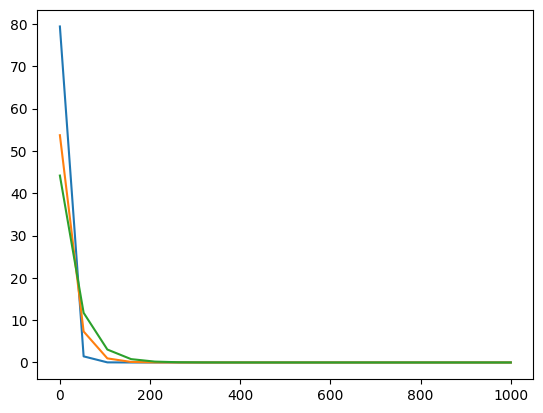

In [11]:
plt.plot(d_lst, rates_2hop)
plt.plot(d_lst, rates_3hop)
plt.plot(d_lst, rates_4hop)
# plt.yscale('log')

In [12]:
np.save("rates_2hop_atom_50", np.array(rates_2hop))
np.save("rates_3hop_atom_50", np.array(rates_3hop))
np.save("rates_4hop_atom_50", np.array(rates_4hop))